# Cinema 興行収入予測モデル - チュートリアル

このノートブックでは、TDD（テスト駆動開発）で実装した Cinema 興行収入予測モデルの使い方を学びます。

## 学習目標

1. 線形回帰モデルの基本理解
2. 欠損値の処理方法
3. 回帰問題の評価指標（R²、MAE、RMSE）
4. モデルの訓練と予測
5. 結果の可視化と解釈

## 1. 環境のセットアップ

In [1]:
import sys
from pathlib import Path

# プロジェクトのルートをパスに追加
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.ml.cinema_predictor import CinemaPredictor

# 日本語フォント設定
plt.rcParams["font.sans-serif"] = ["MS Gothic", "Yu Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("環境のセットアップ完了!")

環境のセットアップ完了!


## 2. データの読み込みと確認

Cinema データセットには、映画の SNS 情報、俳優の人気度、原作の有無などの特徴量と、興行収入（sales）が含まれています。

In [2]:
# モデルの初期化
predictor = CinemaPredictor()

# データの読み込み
X, y = predictor.load_data("../data/cinema.csv")

print(f"データサイズ: {X.shape[0]} サンプル, {X.shape[1]} 特徴量")
print(f"\n特徴量: {list(X.columns)}")
print(f"目的変数: {y.name}")

データサイズ: 100 サンプル, 4 特徴量

特徴量: ['SNS1', 'SNS2', 'actor', 'original']
目的変数: sales


In [3]:
# 最初の 5 行を表示
print("特徴量の最初の 5 行:")
display(X.head())

print("\n目的変数の最初の 5 個:")
display(y.head())

特徴量の最初の 5 行:


,SNS1,SNS2,actor,original
0,291.0,1044,8808.994029,0
1,363.0,568,10290.709370,1
2,158.0,431,6340.388534,1
3,261.0,578,8250.485081,0
4,209.0,683,10908.539550,0



目的変数の最初の 5 個:


0     9731
1    10210
2     8227
3     9658
4     9286
Name: sales, dtype: int64

In [4]:
# データの統計情報
print("特徴量の統計情報:")
display(X.describe())

print("\n目的変数の統計情報:")
display(y.describe())

特徴量の統計情報:


,SNS1,SNS2,actor,original
count,100.000000,100.000000,100.000000,100.000000
mean,370.737374,658.510000,9817.539306,0.500000
std,210.852746,323.839232,1439.476878,0.502519
min,0.000000,0.000000,5702.796056,0.000000
25%,194.750000,443.250000,8824.167215,0.000000
50%,351.500000,654.000000,9922.638363,0.500000
75%,511.750000,885.750000,10791.950398,1.000000
max,1000.000000,1500.000000,12665.073780,1.000000



目的変数の統計情報:


count      100.0000
mean      9882.4300
std        799.2267
min       7869.0000
25%       9314.5000
50%       9965.0000
75%      10440.2500
max      11405.0000
Name: sales, dtype: float64

## 3. データの可視化

各特徴量と目的変数の関係を散布図で確認します。

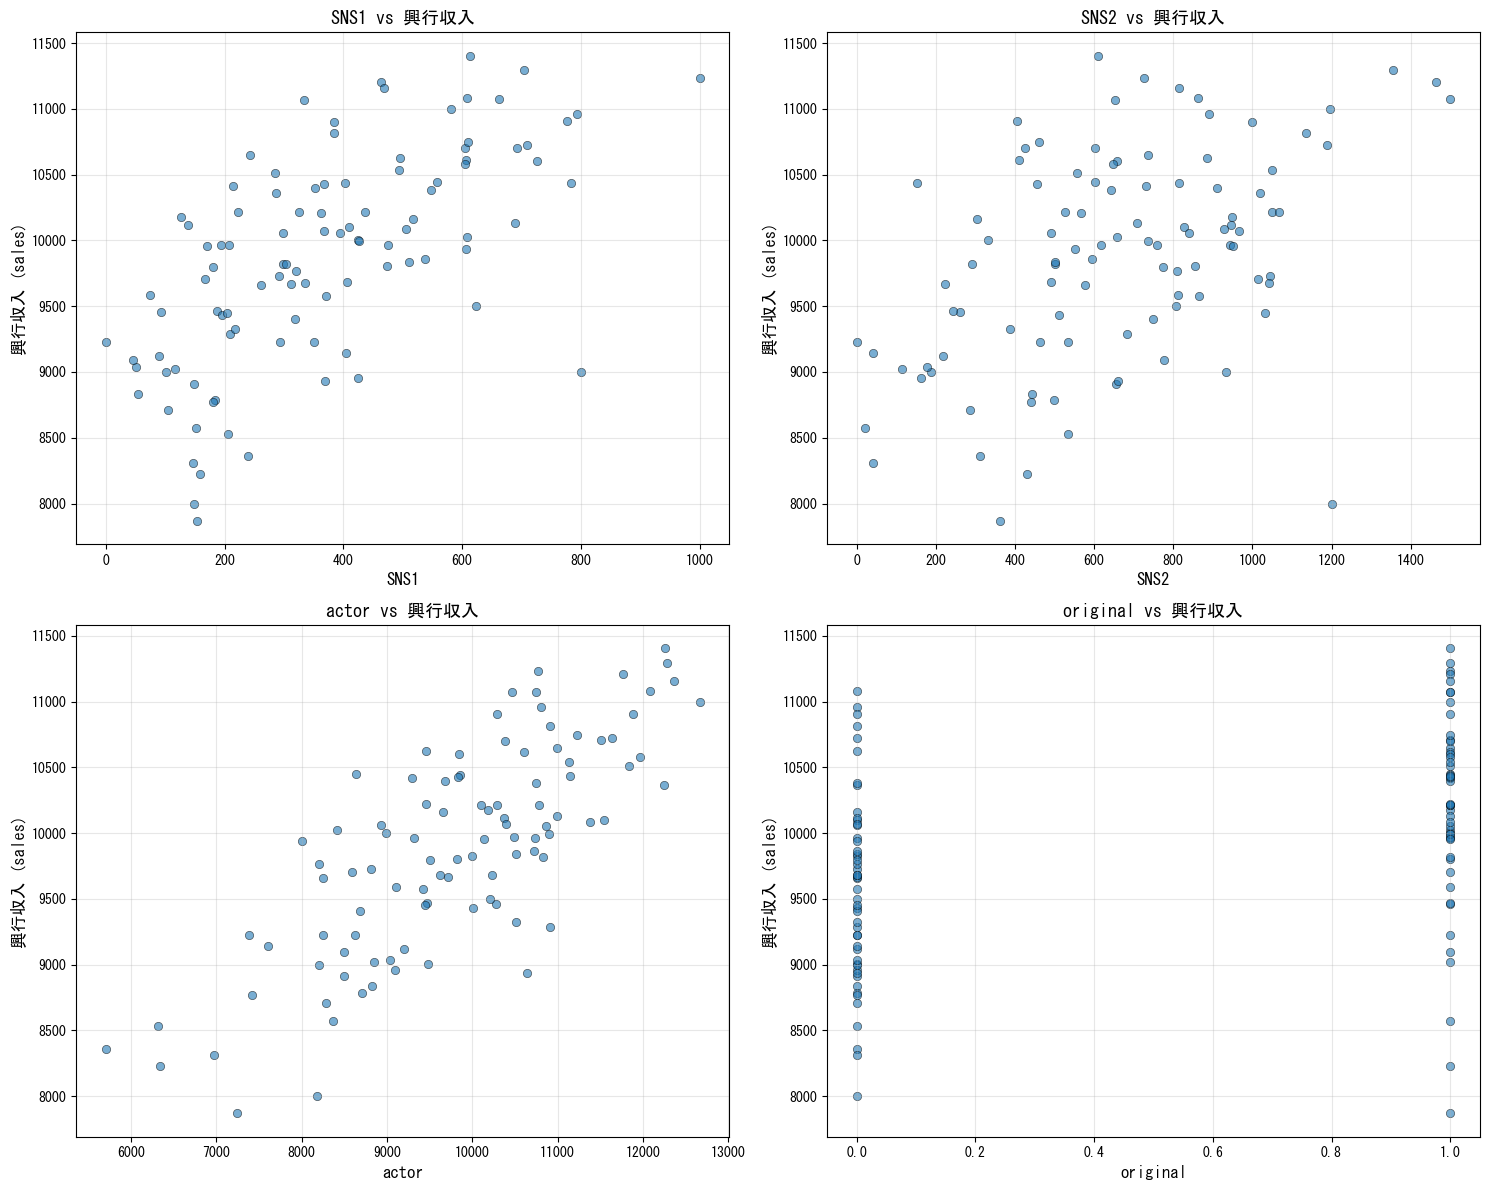

In [5]:
# 各特徴量と目的変数の散布図
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.6, edgecolors="k", linewidth=0.5)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("興行収入 (sales)", fontsize=12)
    axes[i].set_title(f"{col} vs 興行収入", fontsize=13, fontweight="bold")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. モデルの訓練

線形回帰モデルを使って、特徴量から興行収入を予測するモデルを訓練します。

In [6]:
# モデルの訓練
predictor.train(X, y)
print("訓練完了!")

# モデルの係数を確認
print(f"\n切片: {predictor.model.intercept_:.2f}")
print("\n各特徴量の係数:")
for feature, coef in zip(X.columns, predictor.model.coef_):
    print(f"  {feature}: {coef:.4f}")

訓練完了!

切片: 6176.31

各特徴量の係数:
  SNS1: 1.2528
  SNS2: 0.3905
  actor: 0.2908
  original: 259.5456


### 係数の解釈

- **切片**: 全ての特徴量が 0 のときの基準値
- **各係数**: その特徴量が 1 単位増加したときの興行収入の変化量
  - 正の係数: 増加すると興行収入も増加
  - 負の係数: 増加すると興行収入は減少

## 5. モデルの評価

訓練したモデルの性能を評価します。

In [7]:
# 予測
predictions = predictor.predict(X)

# 評価指標の計算
metrics = predictor.evaluate(y, predictions)

print("評価指標:")
print(f"  R² スコア: {metrics['r2']:.4f}")
print(f"  MAE (平均絶対誤差): {metrics['mae']:.2f}")
print(f"  RMSE (二乗平均平方根誤差): {metrics['rmse']:.2f}")

評価指標:
  R² スコア: 0.7597
  MAE (平均絶対誤差): 308.20
  RMSE (二乗平均平方根誤差): 389.85


### 評価指標の解釈

1. **R² スコア (決定係数)**
   - 0～1 の範囲（1 に近いほど良い）
   - モデルが目的変数の分散をどれだけ説明できるか
   - 0.76 = モデルは 76% の分散を説明

2. **MAE (Mean Absolute Error)**
   - 予測値と実測値の絶対誤差の平均
   - 単位: 興行収入と同じ
   - 外れ値の影響を受けにくい

3. **RMSE (Root Mean Squared Error)**
   - 予測値と実測値の二乗誤差の平方根
   - MAE より大きな誤差に敏感
   - 外れ値の影響を受けやすい

## 6. 予測結果の可視化

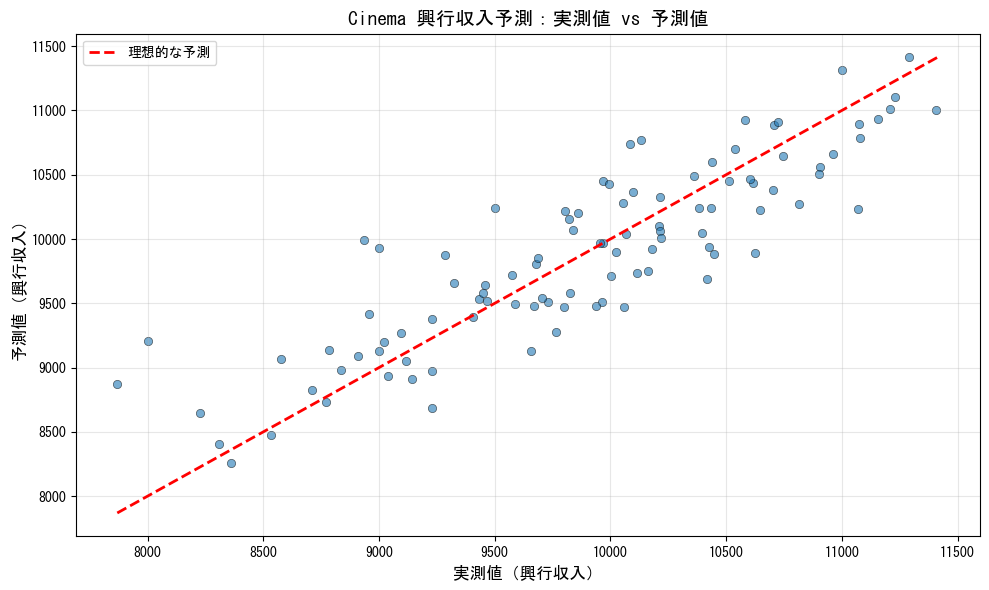

In [8]:
# 実測値 vs 予測値の散布図
plt.figure(figsize=(10, 6))
plt.scatter(y, predictions, alpha=0.6, edgecolors="k", linewidth=0.5)

# 理想的な予測線（y = x）
min_val = min(y.min(), predictions.min())
max_val = max(y.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="理想的な予測")

plt.xlabel("実測値（興行収入）", fontsize=12)
plt.ylabel("予測値（興行収入）", fontsize=12)
plt.title("Cinema 興行収入予測：実測値 vs 予測値", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

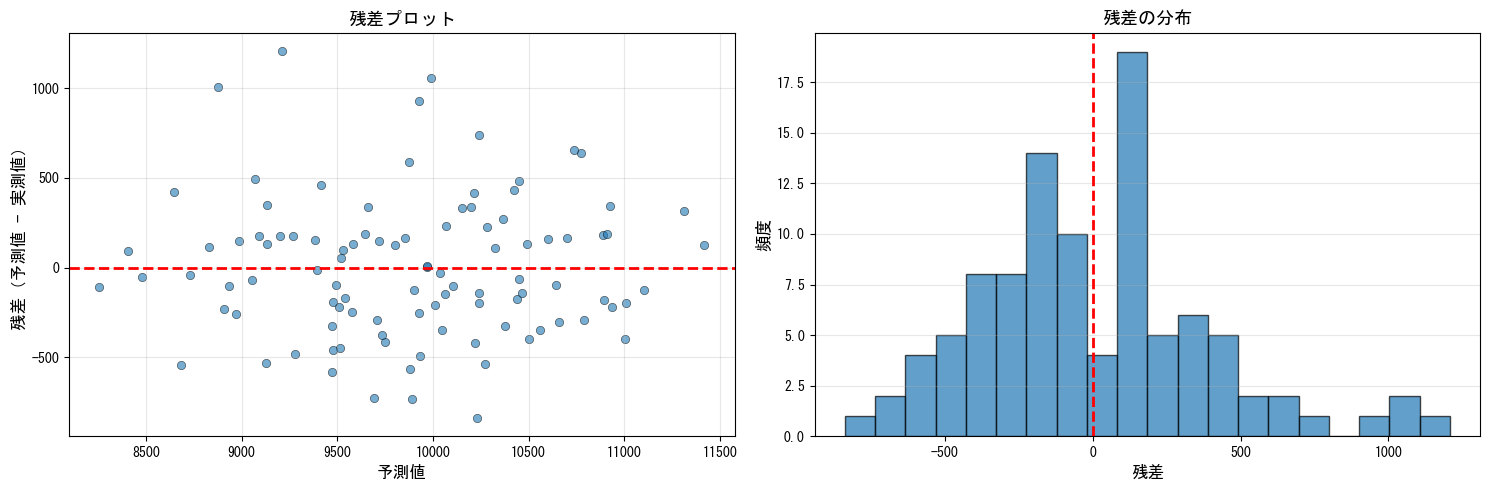

In [9]:
# 残差プロット
residuals = predictions - y

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 残差 vs 予測値
axes[0].scatter(predictions, residuals, alpha=0.6, edgecolors="k", linewidth=0.5)
axes[0].axhline(y=0, color="r", linestyle="--", lw=2)
axes[0].set_xlabel("予測値", fontsize=12)
axes[0].set_ylabel("残差（予測値 - 実測値）", fontsize=12)
axes[0].set_title("残差プロット", fontsize=13, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# 残差のヒストグラム
axes[1].hist(residuals, bins=20, edgecolor="black", alpha=0.7)
axes[1].axvline(x=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("残差", fontsize=12)
axes[1].set_ylabel("頻度", fontsize=12)
axes[1].set_title("残差の分布", fontsize=13, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 7. 新しいデータでの予測

訓練したモデルを使って、新しい映画の興行収入を予測してみます。

In [10]:
# 新しい映画のデータ
new_movies = pd.DataFrame(
    {
        "SNS1": [500, 300, 800],
        "SNS2": [700, 500, 1000],
        "actor": [10000, 8000, 12000],
        "original": [1, 0, 1],
    }
)

print("新しい映画のデータ:")
display(new_movies)

# 予測
new_predictions = predictor.predict(new_movies)

print("\n予測された興行収入:")
for i, pred in enumerate(new_predictions):
    print(f"映画 {i+1}: {pred:.2f}")

新しい映画のデータ:


,SNS1,SNS2,actor,original
0,500,700,10000,1
1,300,500,8000,0
2,800,1000,12000,1



予測された興行収入:
映画 1: 10243.40
映画 2: 9073.64
映画 3: 11317.96


## 8. モデルの保存と読み込み

訓練したモデルを保存して、後で再利用できます。

In [11]:
# モデルの保存
predictor.save_model("../models/cinema_model_notebook.pkl")
print("モデルを保存しました!")

# 新しいインスタンスでモデルを読み込み
new_predictor = CinemaPredictor()
new_predictor.load_model("../models/cinema_model_notebook.pkl")
print("モデルを読み込みました!")

# 同じ予測結果が得られることを確認
new_pred = new_predictor.predict(new_movies)
print("\n読み込んだモデルでの予測:")
for i, pred in enumerate(new_pred):
    print(f"映画 {i+1}: {pred:.2f}")

モデルを保存しました!
モデルを読み込みました!

読み込んだモデルでの予測:
映画 1: 10243.40
映画 2: 9073.64
映画 3: 11317.96


## 9. まとめ

このチュートリアルでは、以下を学びました：

1. ✅ **データの読み込みと前処理**
   - CSV ファイルからのデータ読み込み
   - 欠損値の処理（平均値補完）

2. ✅ **モデルの訓練**
   - 線形回帰モデルの訓練
   - モデルの係数の解釈

3. ✅ **モデルの評価**
   - R²、MAE、RMSE の計算と解釈
   - 残差分析

4. ✅ **予測と可視化**
   - 新しいデータでの予測
   - 結果の可視化

5. ✅ **モデルの永続化**
   - モデルの保存と読み込み

### 次のステップ

- データを訓練セットとテストセットに分割して評価
- 特徴量エンジニアリング（新しい特徴量の作成）
- 他の回帰モデルの試行（Ridge、Lasso、RandomForest など）
- クロスバリデーションによる性能評価